# DBSCAN

**DBSCAN (Density-Based Spatial Clustering of Applications with Noise)**— это метод кластеризации в машинном обучении, основанный на плотности данных.

DBSCAN группирует точки, которые расположены близко друг к другу (в областях высокой плотности), и помечает точки в разреженных областях как шум (outliers).

**Ключевые параметры**

* ε (epsilon) — радиус окрестности точки
* MinPts — минимальное количество точек в ε-окрестности, чтобы точка считалась «плотной»

**Типы точек**

* Core point (ядро) — если в её ε-окрестности ≥ MinPts точек
* Border point (граничная) — меньше MinPts, но находится рядом с ядром
* Noise (шум) — не принадлежит ни одному кластеру

**Как работает алгоритм**

1. Выбирается произвольная точка
2. Проверяется количество соседей в радиусе ε:
3. Если ≥ MinPts → начинается новый кластер
4. Все соседние точки добавляются в кластер
5. Для каждой из этих точек процесс повторяется (если они ядра)
6. Если точка не принадлежит ни одному кластеру → шум
7. Процесс повторяется, пока все точки не будут обработаны

**Kmeans++** — это улучшенная версия K-Means, которая решает проблему плохого выбора начальных центров.

Основная идея в том, чтобы выбирать начальные центры не случайно, а так, чтобы они были максимально удалены друг от друга.

# Используемые библиотеки

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import mode

# Описание и демонстрация датасета

**Iris dataset** — это классический датасет для задач классификации и кластеризации, широко используемый в машинном обучении.

Датасет содержит измерения цветов ириса трёх различных видов:

* Iris setosa
* Iris versicolor
* Iris virginica

In [ ]:
data = load_iris()

X = data.data
y = data.target

feature_names = data.feature_names
target_names = data.target_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [ ]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


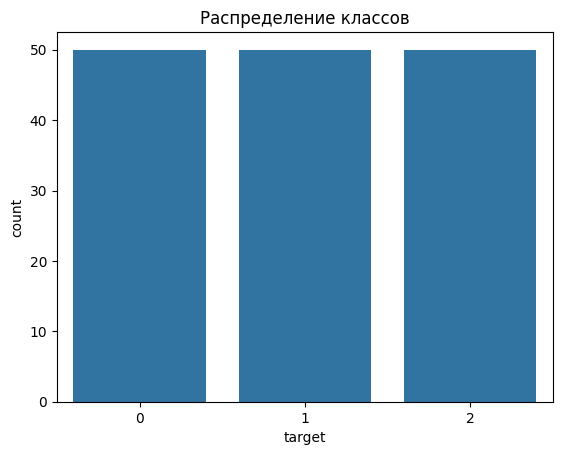

In [ ]:
sns.countplot(x='target', data=df)
plt.title('Распределение классов')
plt.show()

# Препроцессинг датасета

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Обучение модели

**Метод локтя** — это способ определения оптимального количества кластеров (k) в алгоритме K-Means.

**Основная идея**

При увеличении числа кластеров:

* модель лучше подстраивается под данные
* расстояние точек до центров уменьшается

Но после некоторого момента улучшение становится незначительным. Этот «перелом» на графике и называется локтем

In [ ]:
from sklearn.cluster import DBSCAN


dbscan = DBSCAN(eps=0.9, min_samples=4)
y_dbscan = dbscan.fit_predict(X_scaled)

# Оценка качества

In [ ]:
score = silhouette_score(X_scaled, y_dbscan)
print("Silhouette Score:", score)

Silhouette Score: 0.47382345178948004


# Визуализация результатов

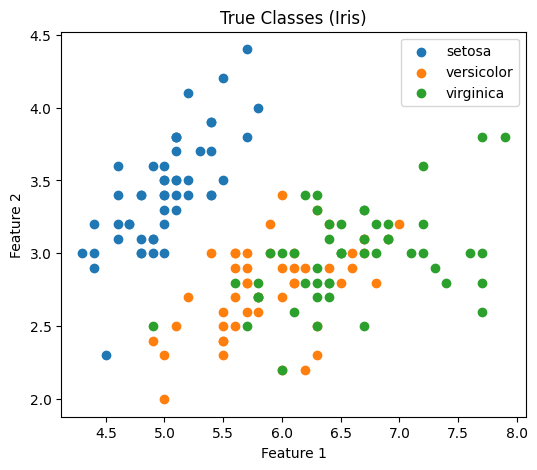

In [ ]:
plt.figure(figsize=(6,5))

for cls in np.unique(y):
    plt.scatter(
        X[y == cls, 0],
        X[y == cls, 1],
        label=data.target_names[cls]
    )

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("True Classes (Iris)")
plt.legend()
plt.show()

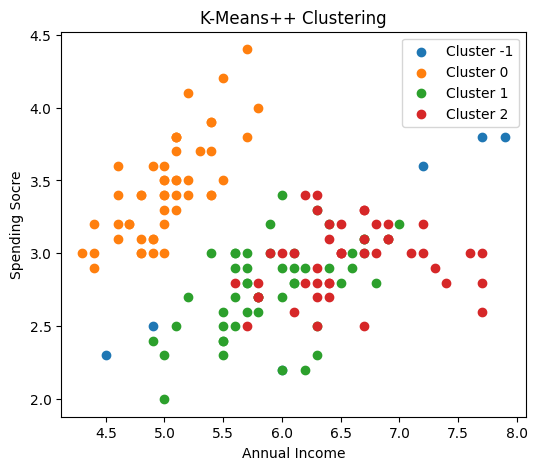

In [ ]:
plt.figure(figsize=(6,5))

for cluster in np.unique(y_dbscan):
    plt.scatter(
        X[y_dbscan == cluster, 0],
        X[y_dbscan == cluster, 1],
        label=f"Cluster {cluster}"
    )

plt.xlabel("Annual Income")
plt.ylabel("Spending Socre")
plt.title("K-Means++ Clustering")
plt.legend()
plt.show()

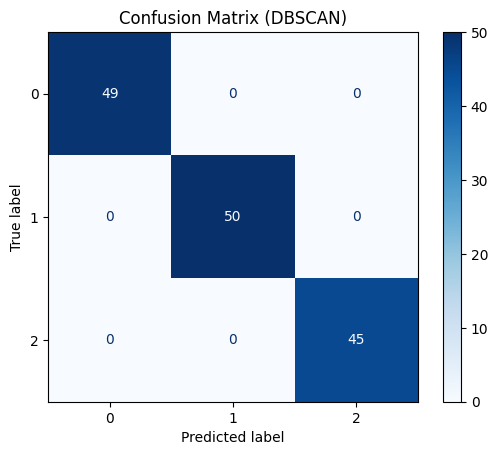

In [ ]:
dbscan_mapped = np.zeros_like(y_dbscan)

for cluster in np.unique(y_dbscan):
    mask = (y_dbscan == cluster)

    if np.sum(mask) == 0:
        continue

    # можно отдельно обработать шум
    if cluster == -1:
        dbscan_mapped[mask] = -1
    else:
        dbscan_mapped[mask] = mode(y[mask], keepdims=True).mode[0]

mask = y_dbscan != -1

cm = confusion_matrix(y[mask], dbscan_mapped[mask])

disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap='Blues')

plt.title('Confusion Matrix (DBSCAN)')
plt.show()